## Deduplicated author analysis

This is a rerun of the comparisons done in excel with messy author names. The deduplicated author lists are from OpenAlex and SciVal, for SFU authors who have more than one publication between 2020-2024. 

The code to generate the deduplicated author lists is found in author_names.ipynb

In [36]:
# import libraries 

import pandas as pd
import numpy as np
import json
import ast
import fuzzywuzzy
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
from datetime import datetime
from tqdm import tqdm 
from collections import defaultdict
import matplotlib.pyplot as plt

In [40]:
oa_auths = pd.read_csv("oa_authors_20-24_deduplicated.csv")
sv_auths = pd.read_csv("sv_authors_20-24_deduplicated.csv")

In [41]:
print("all authors lengths:")
print(len(oa_auths))
print(len(sv_auths))

oa_auths = oa_auths[oa_auths['works_count'] >= 5]
sv_auths = sv_auths[sv_auths['Scholarly Output'] >= 5]

print("auths w/ 5+ pubs: ")
print(len(oa_auths))
print(len(sv_auths))

all authors lengths:
4451
6486
auths w/ 5+ pubs: 
2619
2226


In [99]:
oa_auths['fi_ln'] = oa_auths['first_names'].apply(
    lambda x: ast.literal_eval(x)[0] if ast.literal_eval(x) else ''
) + ' ' + oa_auths['last_name']
oa_auths

,id,orcid,display_name,display_name_alternatives,works_count,cited_by_count,summary_stats,ids,affiliations,last_known_institutions,...,works_api_url,counts_clean,latest_year,pubs_in_latest_yr,name_raw,last_name,last_init,first_names,potential_matches,fi_ln
0,A5114378471,0000-0002-0721-8331,B. Liu,"['B. Liu', 'B L Liu', 'B Liu', 'B X Liu', 'B. ...",2266,110309,"{'2yr_mean_citedness': 6.5344311377245505, 'h_...",{'openalex': 'https://openalex.org/A5114378471...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I126520041', 'ro...",...,https://api.openalex.org/works?filter=author.i...,"[{'year': 1965, 'works_count': 1, 'oa_works_co...",2025,113,b liu,liu,l,['b'],[],b liu
1,A5019316470,0000-0002-7223-2965,M. C. Vetterli,"['M. C. Vetterli', 'A. Vgenopoulos', 'D. Ventu...",1859,105597,"{'2yr_mean_citedness': 5.203389830508475, 'h_i...",{'openalex': 'https://openalex.org/A5019316470...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I1304378839', 'r...",...,https://api.openalex.org/works?filter=author.i...,"[{'year': 1983, 'works_count': 1, 'oa_works_co...",2025,90,m c vetterli,vetterli,v,"['m', 'c']",[],m vetterli
2,A5077377484,0000-0003-0027-7969,J. Llorente Merino,"['J. Llorente Merino', 'J Llorente Merino', 'J...",1681,92792,"{'2yr_mean_citedness': 5.543181818181818, 'h_i...",{'openalex': 'https://openalex.org/A5077377484...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I18014758', 'ror...",...,https://api.openalex.org/works?filter=author.i...,"[{'year': 2008, 'works_count': 1, 'oa_works_co...",2025,64,j llorente merino,merino,m,"['j', 'llorente']",[],j merino
3,A5039614567,0000-0002-7807-7484,M. Danninger,"['M. Danninger', 'Danninger, M.', 'Danninger, ...",1430,62257,"{'2yr_mean_citedness': 5.130434782608695, 'h_i...",{'openalex': 'https://openalex.org/A5039614567...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I18014758', 'ror...",...,https://api.openalex.org/works?filter=author.i...,"[{'year': 2007, 'works_count': 2, 'oa_works_co...",2025,92,m danninger,danninger,d,['m'],[],m danninger
4,A5100397026,0000-0003-1991-119X,Hao Zhang,"['Hao Zhang', 'H. Zhang', 'HAO ZHANG', 'HONG-J...",1370,63147,"{'2yr_mean_citedness': 2.3508771929824563, 'h_...",{'openalex': 'https://openalex.org/A5100397026...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I102345215', 'ro...",...,https://api.openalex.org/works?filter=author.i...,"[{'year': 1993, 'works_count': 2, 'oa_works_co...",2025,44,hao zhang,zhang,z,['hao'],[],hao zhang
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4446,A5084933066,0000-0002-6732-6748,Xing-Dong Yang,"['Xing-Dong Yang', 'None Xing-Dong Yang', 'X. ...",147,3264,"{'2yr_mean_citedness': 1.59375, 'h_index': 33,...",{'openalex': 'https://openalex.org/A5084933066...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I18014758', 'ror...",...,https://api.openalex.org/works?filter=author.i...,"[{'year': 2006, 'works_count': 4, 'oa_works_co...",2025,4,xing-dong yang,yang,y,['xing-dong'],['A5111939848'],xing-dong yang
4447,A5050510999,NaN,M. A. Yakovlev,"['M. A. Yakovlev', 'M Yakovlev', 'M. Yakovlev'...",32,131,"{'2yr_mean_citedness': 2.0, 'h_index': 3, 'i10...",{'openalex': 'https://openalex.org/A5050510999...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I18014758', 'ror...",...,https://api.openalex.org/works?filter=author.i...,"[{'year': 1973, 'works_count': 1, 'oa_works_co...",2025,2,m a yakovlev,yakovlev,y,"['m', 'a']","['A5085376161', 'A5020948201']",m yakovlev
4448,A5067340182,NaN,Judith Lynne Zaichkowsky,"['Judith Lynne Zaichkowsky', 'JUDITH L. ZAICHK...",97,11562,"{'2yr_mean_citedness': 3.5, 'h_index': 27, 'i1...",{'openalex': 'https://openalex.org/A5067340182...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I18014758', 

In [100]:
sv_auths

,Name,Scholarly Output,Most recent publication,Citations,Citations per Publication,Field-Weighted Citation Impact,h-index,Scopus author ID,Scopus author profile,Primary author affiliation*,last_name,last_init,first_names,name_raw,potential_matches,fi_ln
0,"Mori, D.",665,2025,39801,59.900000,3.67,95,56779709600,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,mori,m,d,d mori,[],d mori
1,"van Nieuwkoop, J.",559,2023,42827,76.600000,4.57,108,55573054900,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,van nieuwkoop,v,j,j van nieuwkoop,[],j van nieuwkoop
2,"Horton, Arthur J.",494,2023,35783,72.400000,4.23,95,36898362900,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,horton,h,arthur j,arthur j horton,[],a horton
3,"O'Neil, Dugan C.",473,2023,34795,73.600000,4.37,125,35227745700,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,oneil,o,dugan c,dugan c oneil,[],d oneil
4,"Bahrasemani, H.",466,2025,26153,56.100000,3.44,86,57194525595,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,bahrasemani,b,h,h bahrasemani,[],h bahrasemani
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6479,"Zhang, Zhe George",73,2025,1039,14.232877,0.79,35,57216960787,https://www.scopus.com/authid/detail.url?autho...,Western Washington University,zhang,z,zhe george,zhe george zhang,[np.int64(59224026100)],z zhang
6480,"Zhou, Wen",25,2025,287,11.480000,0.63,14,56565802200,https://www.scopus.com/authid/detail.url?autho...,University of Calgary,zhou,z,wen,wen zhou,"[np.int64(59078330000), np.int64(57226563128)]",w zhou
6481,"Zhang, Xin",26,2023,330,12.692308,0.58,12,56591076800,https://www.scopus.com/authid/detail.url?autho...,Unknown affiliation,zhang,z,xin,xin zhang,"[np.int64(57192507717), np.int64(59760356300),...",x zhang
6482,"Zhao, Yuezhi",12,2022,145,12.083333,2.58,18,37084737400,https://www.scopus.com/authid/detail.url?autho...,Unknown affiliation,zhao,z,yuezhi,yuezhi zhao,[np.int64(59794784100)],y zhao


In [101]:
sv_auths['fi_ln'] = sv_auths['first_names'].apply(lambda x: str(x)[0] if x else '') + ' ' + sv_auths['last_name']
sv_auths

,Name,Scholarly Output,Most recent publication,Citations,Citations per Publication,Field-Weighted Citation Impact,h-index,Scopus author ID,Scopus author profile,Primary author affiliation*,last_name,last_init,first_names,name_raw,potential_matches,fi_ln
0,"Mori, D.",665,2025,39801,59.900000,3.67,95,56779709600,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,mori,m,d,d mori,[],d mori
1,"van Nieuwkoop, J.",559,2023,42827,76.600000,4.57,108,55573054900,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,van nieuwkoop,v,j,j van nieuwkoop,[],j van nieuwkoop
2,"Horton, Arthur J.",494,2023,35783,72.400000,4.23,95,36898362900,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,horton,h,arthur j,arthur j horton,[],a horton
3,"O'Neil, Dugan C.",473,2023,34795,73.600000,4.37,125,35227745700,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,oneil,o,dugan c,dugan c oneil,[],d oneil
4,"Bahrasemani, H.",466,2025,26153,56.100000,3.44,86,57194525595,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,bahrasemani,b,h,h bahrasemani,[],h bahrasemani
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6479,"Zhang, Zhe George",73,2025,1039,14.232877,0.79,35,57216960787,https://www.scopus.com/authid/detail.url?autho...,Western Washington University,zhang,z,zhe george,zhe george zhang,[np.int64(59224026100)],z zhang
6480,"Zhou, Wen",25,2025,287,11.480000,0.63,14,56565802200,https://www.scopus.com/authid/detail.url?autho...,University of Calgary,zhou,z,wen,wen zhou,"[np.int64(59078330000), np.int64(57226563128)]",w zhou
6481,"Zhang, Xin",26,2023,330,12.692308,0.58,12,56591076800,https://www.scopus.com/authid/detail.url?autho...,Unknown affiliation,zhang,z,xin,xin zhang,"[np.int64(57192507717), np.int64(59760356300),...",x zhang
6482,"Zhao, Yuezhi",12,2022,145,12.083333,2.58,18,37084737400,https://www.scopus.com/authid/detail.url?autho...,Unknown affiliation,zhao,z,yuezhi,yuezhi zhao,[np.int64(59794784100)],y zhao


In [10]:
print(len(oa_auths))
oa_auths.head()

4451


,id,orcid,display_name,display_name_alternatives,works_count,cited_by_count,summary_stats,ids,affiliations,last_known_institutions,topics,works_api_url,counts_clean,latest_year,pubs_in_latest_yr,name_raw,last_name,last_init,first_names,potential_matches
0,A5114378471,0000-0002-0721-8331,B. Liu,"['B. Liu', 'B L Liu', 'B Liu', 'B X Liu', 'B. ...",2266,110309,"{'2yr_mean_citedness': 6.5344311377245505, 'h_...",{'openalex': 'https://openalex.org/A5114378471...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I126520041', 'ro...","[{'id': 'https://openalex.org/T10048', 'displa...",https://api.openalex.org/works?filter=author.i...,"[{'year': 1965, 'works_count': 1, 'oa_works_co...",2025,113,b liu,liu,l,['b'],[]
1,A5019316470,0000-0002-7223-2965,M. C. Vetterli,"['M. C. Vetterli', 'A. Vgenopoulos', 'D. Ventu...",1859,105597,"{'2yr_mean_citedness': 5.203389830508475, 'h_i...",{'openalex': 'https://openalex.org/A5019316470...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I1304378839', 'r...","[{'id': 'https://openalex.org/T10048', 'displa...",https://api.openalex.org/works?filter=author.i...,"[{'year': 1983, 'works_count': 1, 'oa_works_co...",2025,90,m c vetterli,vetterli,v,"['m', 'c']",[]
2,A5077377484,0000-0003-0027-7969,J. Llorente Merino,"['J. Llorente Merino', 'J Llorente Merino', 'J...",1681,92792,"{'2yr_mean_citedness': 5.543181818181818, 'h_i...",{'openalex': 'https://openalex.org/A5077377484...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I18014758', 'ror...","[{'id': 'https://openalex.org/T10048', 'displa...",https://api.openalex.org/works?filter=author.i...,"[{'year': 2008, 'works_count': 1, 'oa_works_co...",2025,64,j llorente merino,merino,m,"['j', 'llorente']",[]
3,A5039614567,0000-0002-7807-7484,M. Danninger,"['M. Danninger', 'Danninger, M.', 'Danninger, ...",1430,62257,"{'2yr_mean_citedness': 5.130434782608695, 'h_i...",{'openalex': 'https://openalex.org/A5039614567...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I18014758', 'ror...","[{'id': 'https://openalex.org/T10048', 'displa...",https://api.openalex.org/works?filter=author.i...,"[{'year': 2007, 'works_count': 2, 'oa_works_co...",2025,92,m danninger,danninger,d,['m'],[]
4,A5100397026,0000-0003-1991-119X,Hao Zhang,"['Hao Zhang', 'H. Zhang', 'HAO ZHANG', 'HONG-J...",1370,63147,"{'2yr_mean_citedness': 2.3508771929824563, 'h_...",{'openalex': 'https://openalex.org/A5100397026...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I102345215', 'ro...","[{'id': 'https://openalex.org/T10627', 'displa...",https://api.openalex.org/works?filter=author.i...,"[{'year': 1993, 'works_count': 2, 'oa_works_co...",2025,44,hao zhang,zhang,z,['hao'],[]


In [11]:
print(len(sv_auths))
sv_auths.head()

6486


,Name,Scholarly Output,Most recent publication,Citations,Citations per Publication,Field-Weighted Citation Impact,h-index,Scopus author ID,Scopus author profile,Primary author affiliation*,last_name,last_init,first_names,name_raw,potential_matches
0,"Mori, D.",665,2025,39801,59.9,3.67,95,56779709600,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,mori,m,d,d mori,[]
1,"van Nieuwkoop, J.",559,2023,42827,76.6,4.57,108,55573054900,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,van nieuwkoop,v,j,j van nieuwkoop,[]
2,"Horton, Arthur J.",494,2023,35783,72.4,4.23,95,36898362900,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,horton,h,arthur j,arthur j horton,[]
3,"O'Neil, Dugan C.",473,2023,34795,73.6,4.37,125,35227745700,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,oneil,o,dugan c,dugan c oneil,[]
4,"Bahrasemani, H.",466,2025,26153,56.1,3.44,86,57194525595,https://www.scopus.com/authid/detail.url?autho...,Simon Fraser University,bahrasemani,b,h,h bahrasemani,[]


In [112]:
THRESHOLD = 80

fi_ln_matches = []

sv_grouped = sv_auths.groupby('last_init')
oa_grouped = oa_auths.groupby('last_init')

common_keys = set(sv_grouped.groups.keys()) & set(oa_grouped.groups.keys())

for last_init in tqdm(common_keys):
    sv_group = sv_grouped.get_group(last_init)
    oa_group = oa_grouped.get_group(last_init)

    for _, sv_row in sv_group.iterrows():
        for _, oa_row in oa_group.iterrows():
            # Now fuzzy match on the full fi_ln string
            similarity_score = fuzz.ratio(sv_row['fi_ln'], oa_row['fi_ln'])

            if similarity_score >= THRESHOLD:
                fi_ln_matches.append({
                    'sv_name': sv_row['name_raw'],
                    'oa_name': oa_row['name_raw'],
                    'sv_id': sv_row['Scopus author ID'],
                    'oa_id': oa_row['id'],
                    'sv_pubs': sv_row['Scholarly Output'],
                    'oa_pubs': oa_row['works_count'],
                    'sv_cited': sv_row['Citations'],
                    'oa_cited': oa_row['cited_by_count'],
                    'similarity_score': similarity_score
                })

fi_ln_matches = pd.DataFrame(fi_ln_matches)
display(fi_ln_matches)

100%|██████████| 27/27 [00:30<00:00,  1.14s/it]


,sv_name,oa_name,sv_id,oa_id,sv_pubs,oa_pubs,sv_cited,oa_cited,similarity_score
0,diane gromala,diane gromala,55940625900,A5090850435,50,124,959,2163,82
1,fatima h garcia,fh garcia,57195902689,A5085198235,33,54,282,366,94
2,maya k gislason,maya gislason,26635063500,A5029777875,33,69,572,1018,87
3,erol girt,erol girt,7004753025,A5079115063,30,104,450,1893,80
4,h daniel gibson,h dan gibson,55625662400,A5062475859,30,67,512,1527,100
...,...,...,...,...,...,...,...,...,...
918,karen ruckman,karen ruckman,6506799642,A5024494723,5,19,87,236,82
919,anis rahman,md jamilur rahman,55171845900,A5061642086,5,40,45,249,82
920,k raymond,k raymond,59796861400,A5113816408,5,10,59,83,100
921,lynne marie quarmby,lynne m quarmby,7003446333,A5021180436,15,75,165,3795,82


In [110]:
# first catch and merge all exact matches 
THRESHOLD = 100

perfect_matches = []
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S") 
#filepath = f"./intermediate_results/sv_perfect_name_matches_{timestamp}.csv"

for initial, group in tqdm(sv_auths.groupby('last_init')): 
    names = group['name_raw'].to_list()
    oa_names = oa_auths['name_raw'].to_list()
    
    ids = group['Scopus author ID'].to_list()
    oa_ids = oa_auths['id'].to_list()

    sv_full = group['name_raw'].to_list()
    oa_full = oa_auths['name_raw'].to_list()

    sv_pubs = group['Scholarly Output'].to_list()
    oa_pubs = oa_auths['works_count'].to_list()

    sv_cited = group['Citations'].to_list()
    oa_cited = oa_auths['cited_by_count'].to_list()

    for i in range(len(names)): # SCIVAL
        for j in range(len(names)): # OPENALEX
            sv_name = names[i]
            oa_name = oa_names[j]

            similarity_score = fuzz.ratio(sv_name, oa_name)

            if(similarity_score >= THRESHOLD):
                perfect_matches.append({
                    'sv_name': sv_full[i],
                    'oa_name': oa_full[j], 
                    'sv_id': ids[i], 
                    'oa_id': oa_ids[j], 
                    'sv_pubs': sv_pubs[i], 
                    'oa_pubs': oa_pubs[j], 
                    'sv_cited': sv_cited[i], 
                    'oa_cited': oa_cited[j], 
                    'similarity_score': similarity_score
                })

perfect_matches = pd.DataFrame(perfect_matches)
#perfect_matches.to_csv(filepath)

perfect_matches.head()

100%|██████████| 27/27 [00:09<00:00,  2.72it/s]


,sv_name,oa_name,sv_id,oa_id,sv_pubs,oa_pubs,sv_cited,oa_cited,similarity_score
0,jackson carl burzynski,jackson carl burzynski,57210335824,A5107903626,274,191,3325,2965,100
1,john r best,john r best,34771258200,A5035542400,39,287,270,10622,100
2,joão luiz bastos,joão luiz bastos,12445265000,A5076619980,21,274,49,9453,100
3,zabrina l brumme,zabrina l brumme,57204349045,A5054186329,131,329,2930,11848,100
4,valorie a crooks,valorie a crooks,35585107800,A5057868506,112,254,1165,5924,100


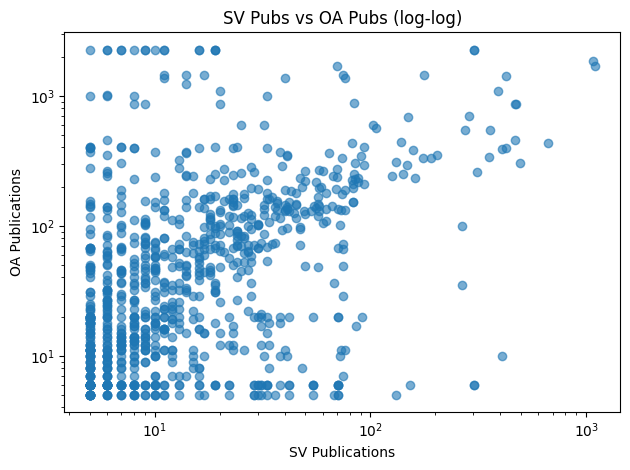

In [113]:
plt.scatter(fi_ln_matches['sv_pubs'], fi_ln_matches['oa_pubs'], alpha=0.6)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('SV Publications')
plt.ylabel('OA Publications')
plt.title('SV Pubs vs OA Pubs (log-log)')

plt.tight_layout()
plt.show()

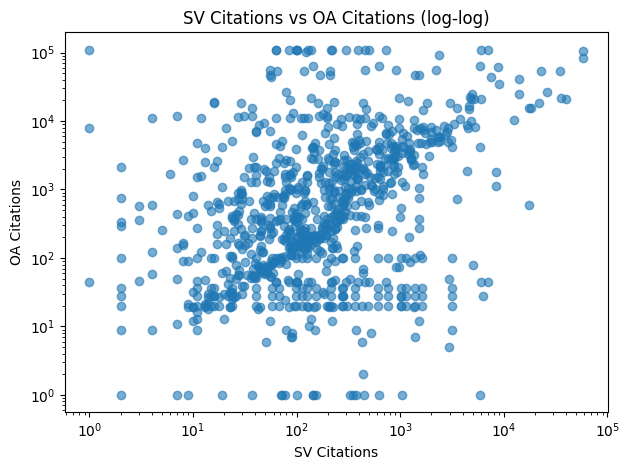

In [114]:
plt.scatter(fi_ln_matches['sv_cited'], fi_ln_matches['oa_cited'], alpha=0.6)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('SV Citations')
plt.ylabel('OA Citations')
plt.title('SV Citations vs OA Citations (log-log)')

plt.tight_layout()
plt.show()

In [28]:
# first catch and merge all exact matches 
THRESHOLD = 100

ln_matches = []
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S") 
filepath = f"./intermediate_results/sv_oa_last_name_matches_{timestamp}.csv"

for initial, group in tqdm(sv_auths.groupby('last_init')): 
    names = group['last_name'].to_list()
    oa_names = oa_auths['last_name'].to_list()
    
    ids = group['Scopus author ID'].to_list()
    oa_ids = oa_auths['id'].to_list()

    sv_full = group['name_raw'].to_list()
    oa_full = oa_auths['name_raw'].to_list()

    sv_pubs = group['Scholarly Output'].to_list()
    oa_pubs = oa_auths['works_count'].to_list()

    sv_cited = group['Citations'].to_list()
    oa_cited = oa_auths['cited_by_count'].to_list()

    #sv_h_index = group['h-index']
    #oa_h_index = oa_auths[]

    for i in range(len(names)): # SCIVAL
        for j in range(len(names)): # OPENALEX
            sv_last_name = names[i]
            oa_last_name = oa_names[j]

            ln_similarity_score = fuzz.ratio(sv_last_name, oa_last_name)

            if(ln_similarity_score >= THRESHOLD):
                full_similarity_score = fuzz.ratio(sv_full[i], oa_full[j])
                ln_matches.append({
                    'sv_name': sv_full[i],
                    'oa_name': oa_full[j], 
                    'sv_id': ids[i], 
                    'oa_id': oa_ids[j], 
                    'sv_pubs': sv_pubs[i], 
                    'oa_pubs': oa_pubs[j], 
                    'sv_cited': sv_cited[i], 
                    'oa_cited': oa_cited[j], 
                    'similarity_score': full_similarity_score
                })

ln_matches = pd.DataFrame(ln_matches)
ln_matches = ln_matches.sort_values(by=['similarity_score'], ascending=False).reset_index().drop(columns=['index'])
ln_matches.to_csv(filepath, index = False)

display(ln_matches)

100%|██████████| 29/29 [00:24<00:00,  1.17it/s]


,sv_name,oa_name,sv_id,oa_id,sv_pubs,oa_pubs,sv_cited,oa_cited,similarity_score
0,kirsten zickfeld,kirsten zickfeld,23010937900,A5032945153,39,172,2128,8984,100
1,hao zhang,hao zhang,59130540100,A5100397026,40,1370,624,63147,100
2,rina zazkis,rina zazkis,6602957344,A5009772411,50,220,357,3736,100
3,jackson carl burzynski,jackson carl burzynski,57210335824,A5107903626,274,191,3325,2965,100
4,ryan w allen,ryan w allen,57203292425,A5039444427,44,125,2434,5183,100
...,...,...,...,...,...,...,...,...,...
1606,sabrina sm lee,kelley lee,27169595700,A5019363540,6,336,65,10321,33
1607,eric ye,zuo‐guang ye,34871175500,A5029972713,4,578,28,20583,32
1608,timothy tl yu,hua‐zhong yu,57218895653,A5028734301,6,245,204,7409,32
1609,jiangchuan chuan liu,b liu,8969748600,A5114378471,301,2266,7109,110309,32
